<a href="https://colab.research.google.com/github/2023atharvvichare/Machine-Learning/blob/main/ML_Experiment_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'insurance' dataset.
Path to dataset files: /kaggle/input/insurance


In [2]:
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
# Download dataset using KaggleHub
path = kagglehub.dataset_download("mirichoi0218/insurance")
print("Dataset Path:", path)

# Load CSV
df = pd.read_csv(f"{path}/insurance.csv")
print(df.head())
print(df.info())


Using Colab cache for faster access to the 'insurance' dataset.
Dataset Path: /kaggle/input/insurance
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.

In [4]:
# Check for null values
print(df.isnull().sum())

# Encode categorical variables
cat_cols = ['sex', 'smoker', 'region']
num_cols = ['age', 'bmi', 'children']

# Define preprocessing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

# Define target
X = df.drop(columns=['charges'])
y = df['charges']


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


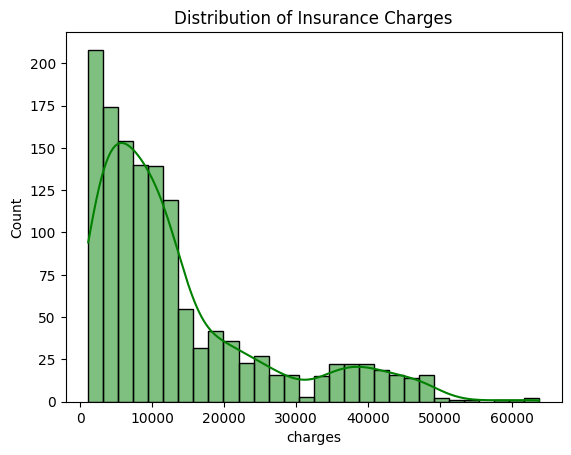

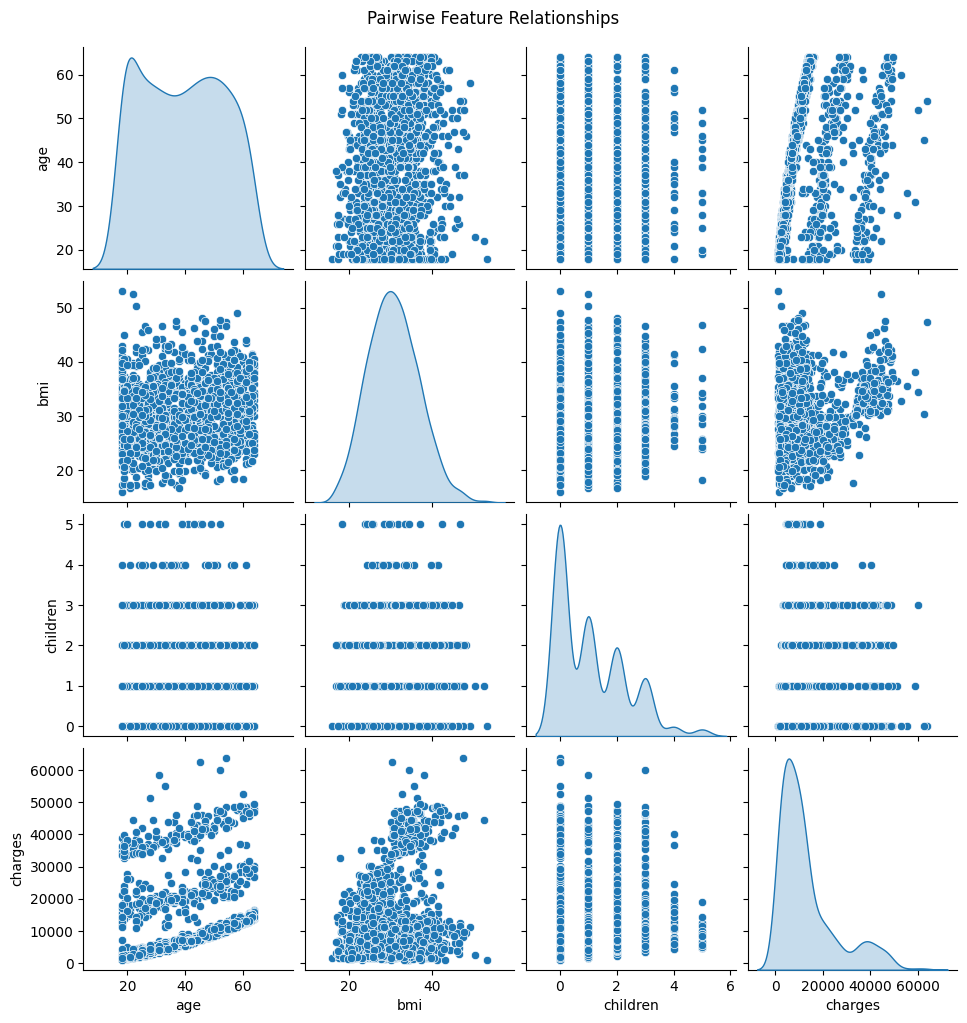

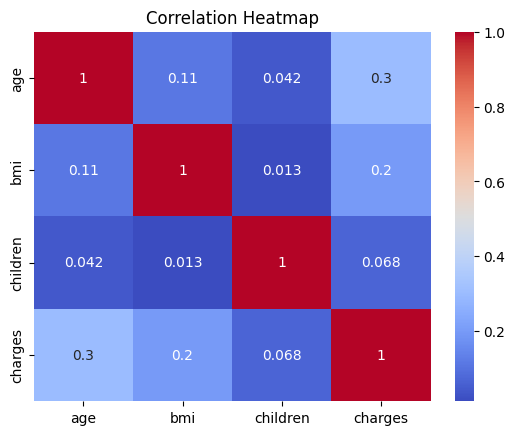

In [5]:
# Distribution of target
sns.histplot(df['charges'], kde=True, color='green')
plt.title('Distribution of Insurance Charges')
plt.show()

# Pairwise relationships
sns.pairplot(df, diag_kind='kde')
plt.suptitle("Pairwise Feature Relationships", y=1.02)
plt.show()

# Correlation heatmap
corr = df[num_cols + ['charges']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
models = {
    'Linear Regression': LinearRegression(),
    'Lasso (L1)': Lasso(alpha=0.1),
    'Ridge (L2)': Ridge(alpha=1.0)
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    scores = cross_val_score(pipeline, X, y, cv=kfold, scoring='r2')
    print(f"{name} → Mean R²: {scores.mean():.4f} | Std: {scores.std():.4f}")


Linear Regression → Mean R²: 0.7402 | Std: 0.0578
Lasso (L1) → Mean R²: 0.7402 | Std: 0.0578
Ridge (L2) → Mean R²: 0.7403 | Std: 0.0571


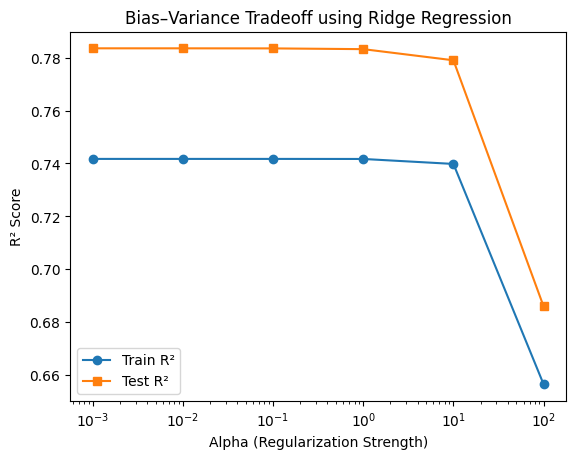

In [8]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
train_r2, test_r2 = [], []

for a in alphas:
    ridge_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=a))
    ])
    ridge_pipeline.fit(X_train, y_train)
    train_r2.append(ridge_pipeline.score(X_train, y_train))
    test_r2.append(ridge_pipeline.score(X_test, y_test))

plt.plot(alphas, train_r2, label='Train R²', marker='o')
plt.plot(alphas, test_r2, label='Test R²', marker='s')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('R² Score')
plt.title('Bias–Variance Tradeoff using Ridge Regression')
plt.legend()
plt.show()
